# The problem 

We see that <sigma_i \sigma_j> terms oscillate quenching from g0 >1  to gf = 0. Under no circumstances should these terms oscillate, as they commute with teh final hamiltonian.

First, we need to verify that the exact solutions do not have this issue, then we need to verify that MY code for computing the observables isn't the issue, then we can finally deduce that it is only the numerical solutiosn that have the problem. Be systematic. Be cool. This can be done efficiently!

In [3]:
import sys
sys.path.append("../../src/")
import TFIM_operators_from_states as op

from project_imports import *

In [ ]:
def Vt(V0,gf,t):
    u0,v0,k= V0
    at = [ a(gf,ki) for ki in k]
    bt = [ b(gf,ki) for ki in k]
    wt = [ om(gf,ki) for ki in k ]    
    ut = array([u0q*cos(2*wtq*t)+(1j/wtq)*(aq*u0q+bq*v0q)*sin(2*wtq*t) for u0q,v0q,wtq,aq,bq in zip(u0,v0,wt,at,bt)])
    vt = array([-1j*v0q*cos(2*wtq*t)+(bq*u0q-aq*v0q)*sin(2*wtq*t)/wtq for u0q,v0q,wtq,aq,bq in zip(u0,v0,wt,at,bt)]  )
    return [ut,vt,k]


In [184]:
def a(g,q):
    return g+cos(q)
def b(g,q):
    return sin(q)
def om(g,q):
    return sqrt(g*g+2*g*cos(q)+1)
def theta(g,q):
    return np.atan2(b(g,q),a(g,q))
def u(g,q):
    num = a(g,q)-om(g,q)
    denom = sqrt(2*om(g,q) *( om(g,q)-a(g,q)))
   # f=-2*np.array([[a(g,q),1j*b(g,q)],[-1j*b(q,g),-a(g,q)]])
   # test= la.eigh(f)[1][:,1][0]
    th = theta(g,q)
    return cos(th/2)#num/denom

def v(g,q):
    num = b(g,q)
    denom = sqrt(2*om(g,q) *( om(g,q)-a(g,q)))
    #f=-2*np.array([[a(g,q),1j*b(g,q)],[-1j*b(q,g),-a(g,q)]])
    #test= la.eigh(f)[1][:,1][1]
    th= theta(g,q)
    return sin(th/2)#num/denom

def V0(g,L):
    k = array([2*pi/L *(n +1/2) for n in np.arange(-L//2,L//2)])
    us =array([u(g,ki) for ki in k])
    vs = array([v(g,ki) for ki in k])
    return [us,vs,k]


def G(r,s):
    u0,v0,k= s
    av =np.average((u0+v0)*(np.conj(u0)-np.conj(v0))*np.exp(1j*k*r))
    term_one = cos(k*r)*(abs(u0)**2-abs(v0)**2 )
    term_two= sin(k*r)*np.imag(np.conj(u0)*v0)#(u0*np.conj(v0)-v0*np.conj(u0))
    return -np.average(term_one+term_two)


# r method


In [185]:
def Rq(g,q):
    uq= u(g,q)
    vq= v(g,q)
    R = array([[uq,1j*vq],[1j*vq,uq]])
    return R

def evo_matrix(g,q,t):
    R = Rq(g,q)
    phase = np.exp(2j*t*om(g,q))
    U = array([[phase,0],[0,np.conj(phase)]])

    return R@U@np.conj(R.T)



def Vt(V0,gf,t):
    u0,v0,k= V0
    evo_matrices = [evo_matrix(gf,ki,t) for ki in k]
    ut=[]
    vt=[]
    for u,v,U in zip(u0,v0,evo_matrices):
        vec = array([u,1j*v])
        vect = U@vec
        ut.append(vect[0])
        vt.append(vect[1])
            


    return [ut,vt,k]


In [194]:
vec0 = V0(0.,100)
vect=[Vt(vec0,0,ti) for ti in t];
sx = [op.sx_correlation([0,1],v) for v in vect]


(-1.0, 1.0)

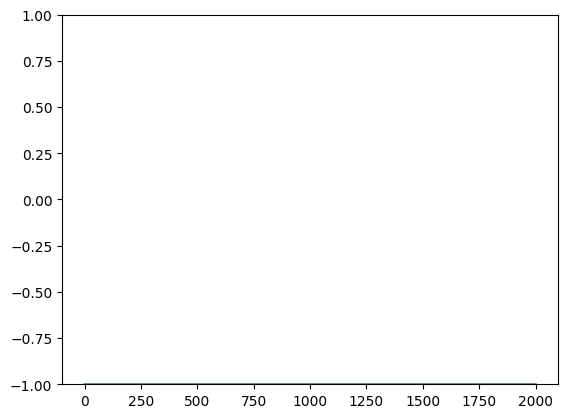

In [195]:
plot(sx)
ylim(-1,1)